# **PRAKTIKUM PERTEMUAN 9 DATA SCIENCE**

Nama : Ninis Indah Trisia

NIM : 250401020094

Kelas : IF405

### Langkah 1 Memuat Dataset dan Eksplorasi Data Awal

In [11]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset
cancer = load_breast_cancer()

# Membentuk dataframe fitur dan target
X = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

y = pd.Series(cancer.target)

print("Jumlah data dan fitur :", X.shape)

Jumlah data dan fitur : (569, 30)


In [12]:
# Melihat proporsi masing-masing kelas
kelas = y.replace({
    0: "Malignant",
    1: "Benign"
})

distribusi = (
    kelas.value_counts(normalize=True)
    .round(3)
)

print("Distribusi kelas:")
print(distribusi)

Distribusi kelas:
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


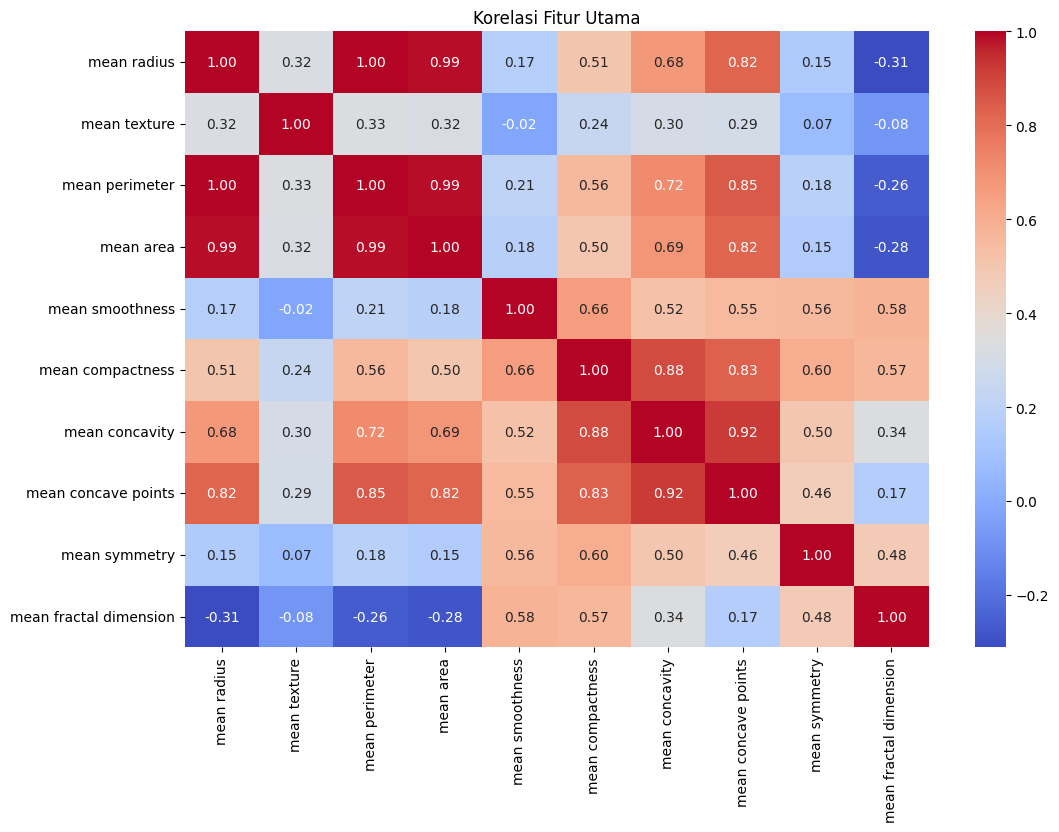

In [13]:
# Menampilkan korelasi beberapa fitur utama
plt.figure(figsize=(12, 8))

sns.heatmap(
    X.iloc[:, :10].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasi Fitur Utama")
plt.show()

Hasil Pengamatan Awal

Dataset terdiri atas 569 sampel dengan 30 fitur numerik yang menggambarkan karakteristik sel hasil pemeriksaan medis.

Distribusi kelas menunjukkan bahwa jumlah data Benign lebih banyak dibandingkan Malignant, namun kedua kelas masih memiliki proporsi yang cukup baik untuk proses klasifikasi.

Dari matriks korelasi terlihat bahwa beberapa fitur yang berhubungan dengan ukuran sel, seperti radius, perimeter, dan area, memiliki hubungan yang cukup kuat. Kondisi ini menunjukkan bahwa karakteristik ukuran sel kemungkinan memiliki kontribusi penting dalam membedakan sel jinak dan sel ganas.

### Langkah 2 Persiapan Data (Preprocessing)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Membagi data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data latih :", X_train.shape)
print("Data uji   :", X_test.shape)

Data latih : (455, 30)
Data uji   : (114, 30)


In [15]:
# Standardisasi data untuk Logistic Regression
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Tahap Persiapan Data

Pembagian data dilakukan dengan rasio 80:20, yaitu 80% digunakan sebagai data pelatihan dan 20% sebagai data pengujian. Penggunaan parameter `stratify=y` bertujuan agar proporsi data Malignant dan Benign tetap terjaga pada kedua kelompok data.

Selanjutnya dilakukan standardisasi menggunakan StandardScaler. Tahap ini diperlukan karena Logistic Regression bekerja lebih optimal ketika seluruh fitur berada pada skala yang sebanding.

### Langkah 3 Membangun Model Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi model
log_model = LogisticRegression(
    max_iter=5000
)

# Pelatihan model
log_model.fit(
    X_train_s,
    y_train
)

# Prediksi data uji
y_pred_log = log_model.predict(
    X_test_s
)

In [17]:
# Menampilkan fitur yang paling berpengaruh
coef_df = pd.DataFrame({
    "Nama Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
})

coef_df = coef_df.reindex(
    coef_df["Koefisien"]
    .abs()
    .sort_values(ascending=False)
    .index
)

coef_df.head(10)

,Nama Fitur,Koefisien
21,worst texture,-1.255088
10,radius error,-1.082965
27,worst concave points,-0.953686
23,worst area,-0.947756
20,worst radius,-0.947616
28,worst symmetry,-0.939181
13,area error,-0.929104
26,worst concavity,-0.823151
22,worst perimeter,-0.763220
24,worst smoothness,-0.746625


Interpretasi Model Logistic Regression

Nilai koefisien menunjukkan besarnya pengaruh setiap fitur terhadap hasil prediksi. Semakin besar nilai absolut koefisien, semakin besar pula kontribusi fitur tersebut dalam proses klasifikasi.

Fitur yang berkaitan dengan ukuran, bentuk, dan kepadatan sel umumnya menjadi fitur yang paling dominan. Hal ini menunjukkan bahwa perubahan karakteristik sel memiliki hubungan yang kuat terhadap kemungkinan suatu sampel dikategorikan sebagai sel ganas atau sel jinak.

### Langkah 4 – Membangun Model Decision Tree

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Membuat model
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Pelatihan model
tree_model.fit(
    X_train,
    y_train
)

# Prediksi
y_pred_tree = tree_model.predict(
    X_test
)

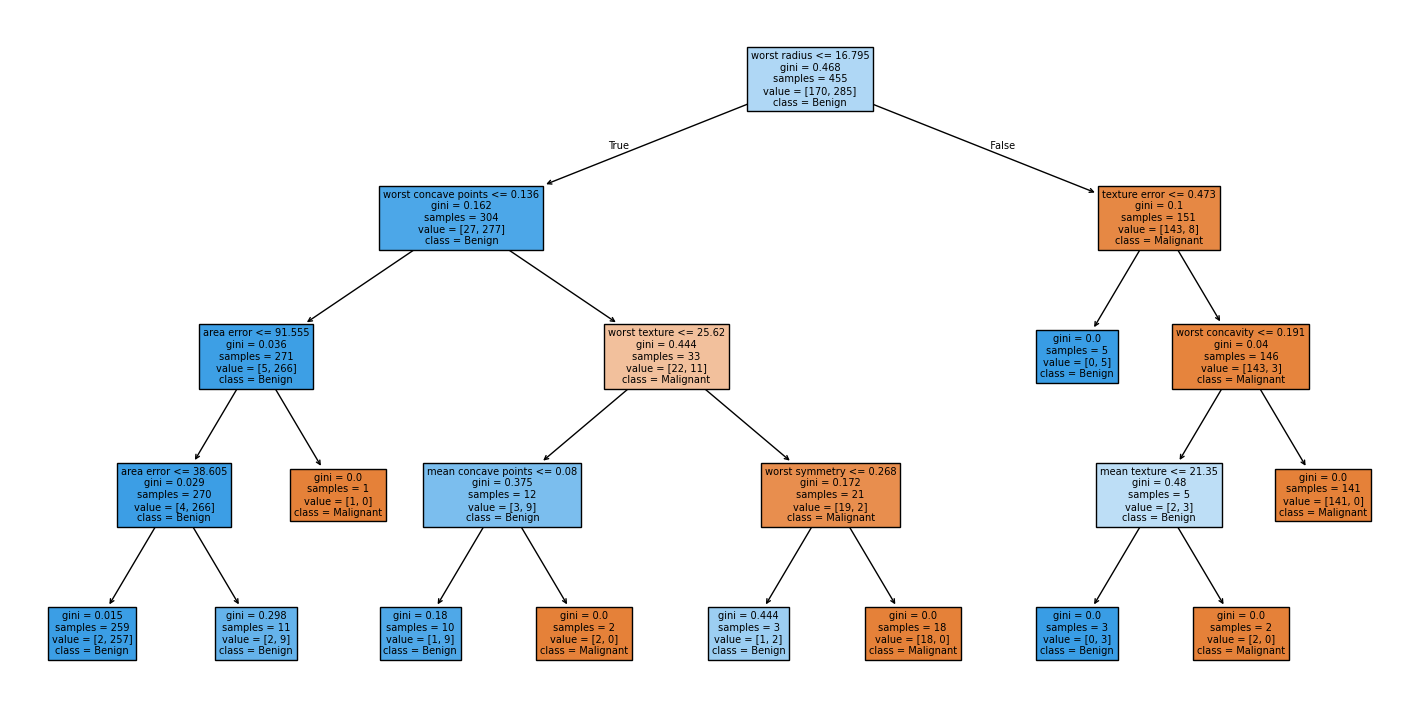

In [19]:
# Visualisasi pohon keputusan
plt.figure(figsize=(18, 9))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True
)

plt.show()

Interpretasi Decision Tree

Decision Tree membentuk serangkaian aturan keputusan berdasarkan fitur yang dianggap paling informatif. Setiap percabangan menunjukkan kondisi tertentu yang digunakan model untuk mengelompokkan data ke dalam kategori Malignant atau Benign.

Kelebihan algoritma ini adalah proses pengambilan keputusan dapat dipahami secara visual sehingga lebih mudah diinterpretasikan dibandingkan beberapa algoritma klasifikasi lainnya.

### Langkah 5 Mengukur dan Membandingkan Performa Model

In [20]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Menyimpan nama model dan hasil prediksi
hasil_prediksi = [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_tree)
]

# Menampilkan metrik evaluasi setiap model
for nama_model, prediksi in hasil_prediksi:

    cm = confusion_matrix(y_test, prediksi)
    acc = accuracy_score(y_test, prediksi)
    prec = precision_score(y_test, prediksi)
    rec = recall_score(y_test, prediksi)
    f1 = f1_score(y_test, prediksi)

    print(f"\n{'='*45}")
    print(f"Hasil Evaluasi : {nama_model}")
    print(f"{'='*45}")

    print("Confusion Matrix")
    print(cm)

    print(f"Accuracy  : {acc:.3f}")
    print(f"Precision : {prec:.3f}")
    print(f"Recall    : {rec:.3f}")
    print(f"F1-Score  : {f1:.3f}")


Hasil Evaluasi : Logistic Regression
Confusion Matrix
[[41  1]
 [ 1 71]]
Accuracy  : 0.982
Precision : 0.986
Recall    : 0.986
F1-Score  : 0.986

Hasil Evaluasi : Decision Tree
Confusion Matrix
[[39  3]
 [ 4 68]]
Accuracy  : 0.939
Precision : 0.958
Recall    : 0.944
F1-Score  : 0.951


Analisis Hasil Evaluasi

Accuracy menunjukkan seberapa banyak prediksi yang benar dari seluruh data pengujian.

Precision menggambarkan ketepatan model ketika memberikan prediksi positif.

Recall menunjukkan kemampuan model dalam menemukan seluruh kasus positif yang benar-benar ada pada data.

F1-Score digunakan untuk melihat keseimbangan antara Precision dan Recall.

Pada kasus diagnosis kanker, Recall memiliki peran yang sangat penting. Nilai Recall yang tinggi menunjukkan bahwa model mampu mendeteksi lebih banyak pasien yang benar-benar menderita kanker sehingga risiko False Negative dapat dikurangi.

### Kesimpulan

Praktikum ini menunjukkan bahwa algoritma Logistic Regression dan Decision Tree dapat diterapkan untuk menyelesaikan permasalahan klasifikasi pada diagnosis kanker payudara menggunakan dataset Breast Cancer Wisconsin.

Tahapan yang dilakukan meliputi eksplorasi data, preprocessing, pelatihan model, hingga evaluasi menggunakan beberapa metrik klasifikasi.

Pada kasus medis, model tidak cukup dinilai hanya dari Accuracy yang tinggi. Kemampuan model dalam mendeteksi seluruh pasien yang benar-benar menderita kanker menjadi pertimbangan utama. Oleh karena itu, nilai Recall perlu menjadi fokus utama dalam menentukan model terbaik karena semakin tinggi Recall, semakin kecil kemungkinan kasus kanker tidak terdeteksi oleh sistem.

Model yang menghasilkan Recall tertinggi dapat dianggap lebih layak digunakan sebagai pendukung proses diagnosis awal kanker payudara.